                              Airbnb All-Time Stock Price Analysis

**Information**

**Airbnb, Inc. is a global online marketplace** that connects hosts offering short-term lodging and experiences with travelers around the world. Headquartered in **San Francisco, California, USA,** Airbnb was founded in 2008 and has revolutionized the travel and hospitality industry by enabling peer-to-peer accommodation and experience-based travel.

Airbnb’s platform **allows users to book homes, apartments, vacation rentals, and unique stays, as well as local experiences.** The company operates across millions of listings in numerous countries, supporting tourism, remote work travel, and alternative lodging solutions.

Airbnb, Inc. is **publicly traded on the NASDAQ under the ticker symbol ABNB**, with stock prices denominated in US Dollars (USD).

With a market capitalization typically in the tens to hundreds of billions of USD (subject to market conditions), **Airbnb is one of the most prominent companies in the global travel technology sector.** Market capitalization represents the total market value of a company’s outstanding shares and reflects its market influence and scale.


📌 **1. Introduction & Objective**

This notebook presents a complete exploratory and business-focused analysis of Airbnb (ABNB) stock price data. The dataset contains daily trading information such as open, high, low, close prices, adjusted close price and trading volume.

🎯 **Objectives**

- Understand long-term and short-term stock price behavior

- Analyze volatility and trading activity

- Identify patterns useful for investors and analysts

- Provide actionable business recommendations

📁 **2. Dataset Information**

- **Geography:** Global

- **Time Period:** All available historical data

- **Unit of Analysis:** Airbnb, Inc. stock price data

- **Currency:** USD

🧾 **Variables Description**

- **date** -	Trading date

- **open** -	Opening price at the start of the trading session

- **high** -	Highest price reached during the trading day

- **low** -	Lowest price recorded during the trading day

- **close** -	Closing price at the end of the trading day

- **adj_close** -	Adjusted closing price accounting for stock splits and dividends

- **volume** -	Total number of shares traded during the day

#### **3. Importing Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### **4. Data Loading**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/airbnb.csv')
df.head()

,date,open,high,low,close,adj_close,volume
0,10-12-2020,144.710007,144.710007,165.000000,141.250000,146.000000,70447500
1,11-12-2020,139.250000,139.250000,151.500000,135.100006,146.550003,26980800
2,14-12-2020,130.000000,130.000000,135.300003,125.160004,135.000000,16966100
3,15-12-2020,124.800003,124.800003,127.599998,121.500000,126.690002,10914400
4,16-12-2020,137.990005,137.990005,142.000000,124.910004,125.830002,20409600


#### **5. Data Assessment**

**5.1 Structure & Summary**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271 entries, 0 to 1270
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       1271 non-null   object 
 1   open       1271 non-null   float64
 2   high       1271 non-null   float64
 3   low        1271 non-null   float64
 4   close      1271 non-null   float64
 5   adj_close  1271 non-null   float64
 6   volume     1271 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 69.6+ KB


In [4]:
df.describe()

,open,high,low,close,adj_close,volume
count,1271.000000,1271.000000,1271.000000,1271.000000,1271.000000,1.271000e+03
mean,137.729862,137.729862,140.233318,135.165246,137.650646,5.864662e+06
std,24.078928,24.078928,24.897157,23.398056,24.167229,4.531248e+06
min,82.489998,82.489998,84.250000,81.910004,82.970001,1.457200e+06
25%,120.850002,120.850002,122.840000,118.895001,120.720001,3.768450e+06
50%,135.020004,135.020004,136.820007,132.889999,134.910004,4.772600e+06
75%,151.660004,151.660004,154.459999,148.650497,151.090004,6.482950e+06
max,216.839996,216.839996,219.940002,209.089996,216.240005,7.478850e+07


**5.2 Initial Observations**

- Wide range of stock prices

- Volume shows high variability

- Time-series structure detected

#### **6. Data Pre-processing**

**6.1 Date Handling**

In [5]:
df['date'] = pd.to_datetime(df['date'],format='mixed',
    dayfirst=False,
    errors='coerce')

In [6]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271 entries, 0 to 1270
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1271 non-null   datetime64[ns]
 1   open       1271 non-null   float64       
 2   high       1271 non-null   float64       
 3   low        1271 non-null   float64       
 4   close      1271 non-null   float64       
 5   adj_close  1271 non-null   float64       
 6   volume     1271 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 69.6 KB
None
        date        open        high         low       close   adj_close  \
0 2020-10-12  144.710007  144.710007  165.000000  141.250000  146.000000   
1 2020-11-12  139.250000  139.250000  151.500000  135.100006  146.550003   
2 2020-12-14  130.000000  130.000000  135.300003  125.160004  135.000000   
3 2020-12-15  124.800003  124.800003  127.599998  121.500000  126.690002   
4 2020-12-16  13

#### **7. Data Cleaning**

**7.1 Missing Values**

In [7]:
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


**7.2 Duplicate Records**

In [8]:
df.duplicated().sum()

np.int64(0)

#### **8. Feature Engineering**

In [9]:
# Daily return percentage
df['daily_return_pct'] = df['adj_close'].pct_change()*100

# Price volatility
df['price_range'] = df['high'] - df['low']

# Date features
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.day_name()

#### **9. Exploratory Data Analysis (EDA)**

**9.1 Univariate Analysis**

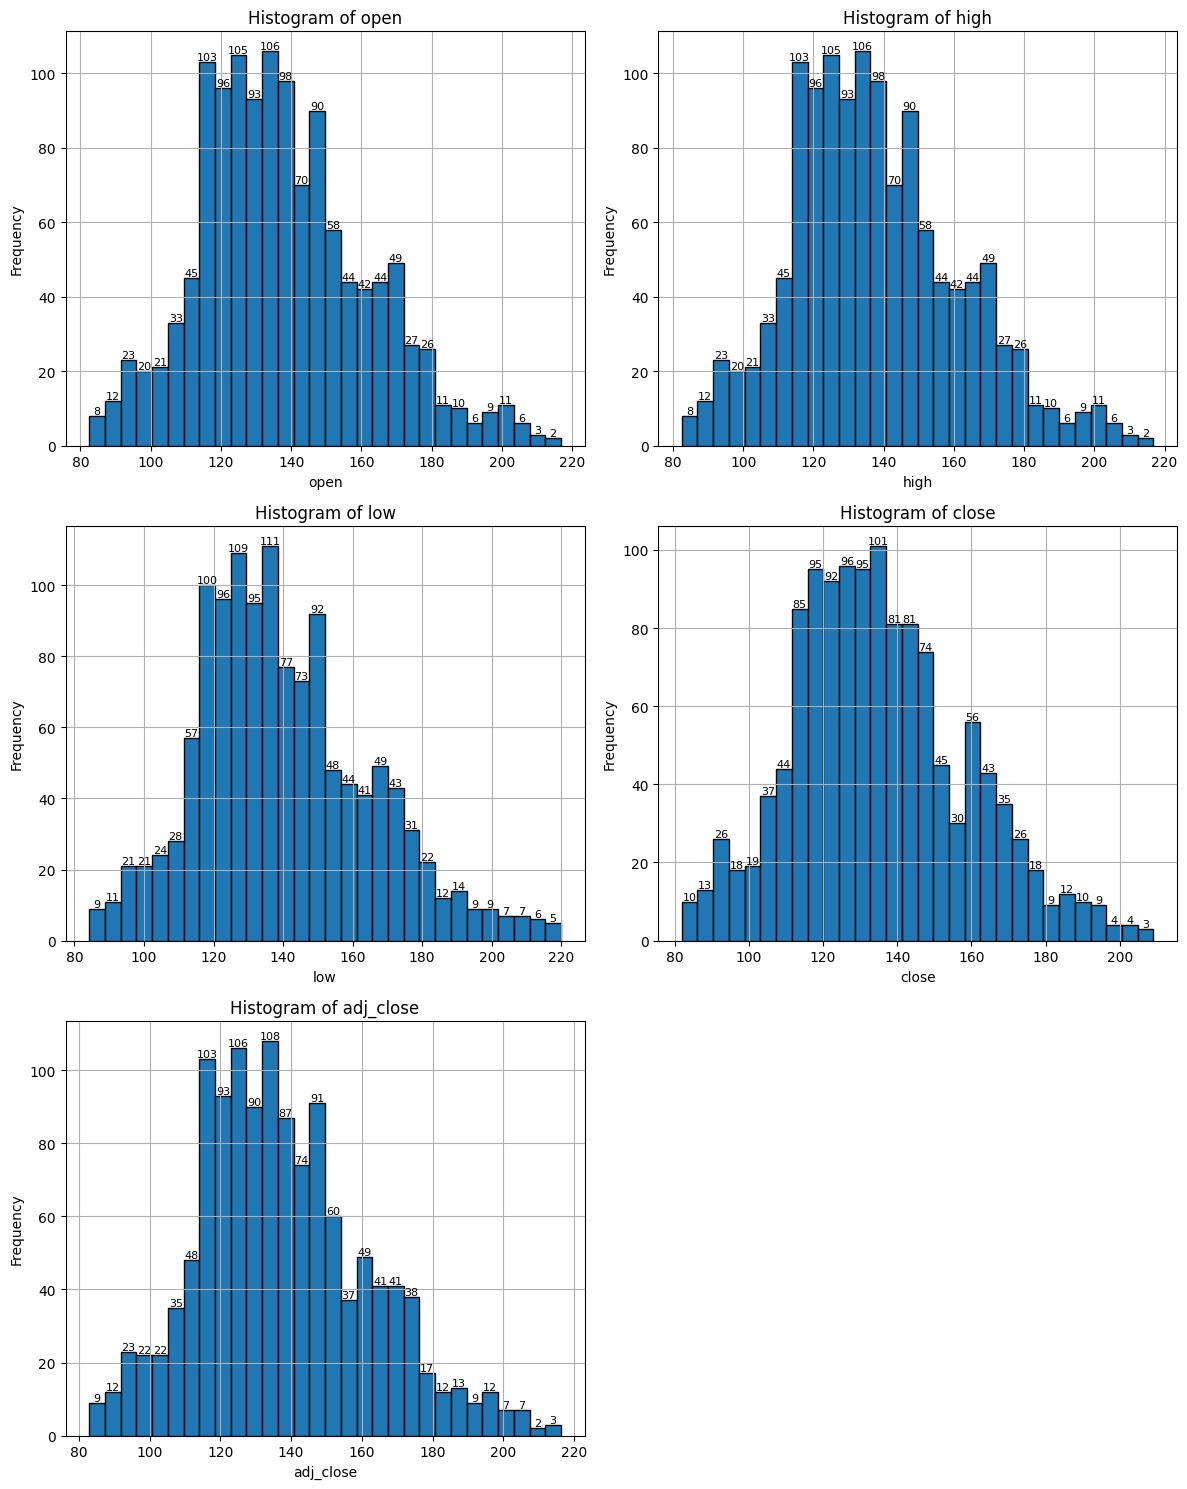

In [10]:
# Distribution of Adjusted Close Price
import math

price_cols = ['open', 'high', 'low', 'close', 'adj_close']

n_cols = 2
n_rows = math.ceil(len(price_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    data = df[col].dropna()

    counts, bins, patches = axes[i].hist(
        data,
        bins=30,
        edgecolor='black'
    )

    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

# Adding Data Labels on each Bar
    for count, patch in zip(counts, patches):
        if count > 0:
            axes[i].text(
                patch.get_x() + patch.get_width() / 2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=8
            )

# Removing extra empty subplot
for j in range(len(price_cols), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

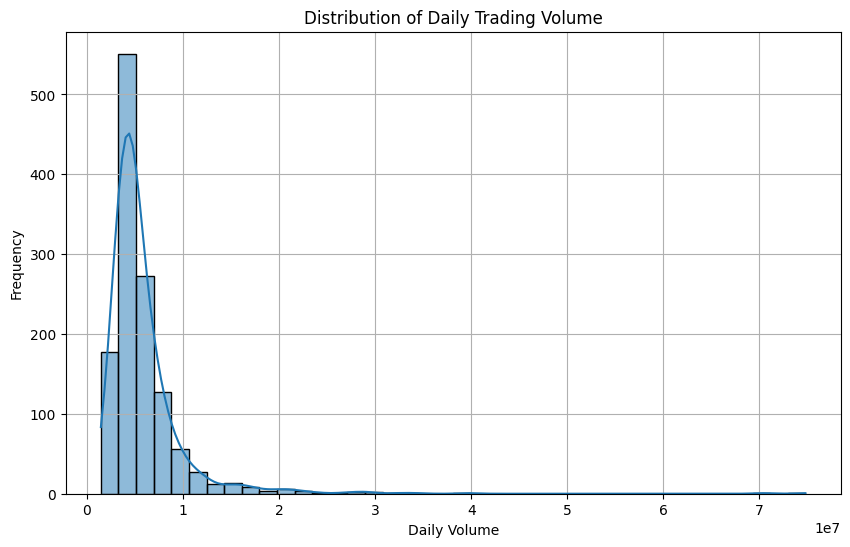

In [11]:
# Distribution of Daily Trading Volume
plt.figure(figsize=(10,6))
sns.histplot(df['volume'], bins=40, kde=True)
plt.title("Distribution of Daily Trading Volume")
plt.xlabel("Daily Volume")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

* **Right-skewed distribution** → Normal in stocks

* **Long tail** → Occasional high-activity days

* **Multiple peaks** → Possible regime changes

**Detecting Unusually High-Volume Days**

In [12]:
# Method : Z-Score (Statistical Outliers)
df['volume_zscore'] = (df['volume'] - df['volume'].mean()) / df['volume'].std()

high_volume_days = df[df['volume_zscore'] > 3]   # threshold = 3 std

high_volume_days

,date,open,high,low,close,adj_close,volume,daily_return_pct,price_range,month,year,day_of_week,volume_zscore
0,2020-10-12,144.710007,144.710007,165.000000,141.250000,146.000000,70447500,NaN,-20.289993,10,2020,Monday,14.252770
1,2020-11-12,139.250000,139.250000,151.500000,135.100006,146.550003,26980800,0.376714,-12.250000,11,2020,Thursday,4.660115
4,2020-12-16,137.990005,137.990005,142.000000,124.910004,125.830002,20409600,-0.678823,-4.009995,12,2020,Wednesday,3.209919
106,2021-05-14,141.199997,141.199997,142.250000,131.669998,137.679993,20325400,-3.212659,-1.050003,5,2021,Friday,3.191337
107,2021-05-17,132.500000,132.500000,137.789993,130.253006,137.156006,39755000,-0.380583,-5.289993,5,2021,Monday,7.479250
115,2021-05-27,143.169998,143.169998,143.820007,134.500000,135.070007,21270200,0.096343,-0.650009,5,2021,Thursday,3.399844
176,2021-08-24,161.419998,161.419998,161.979996,146.500000,147.000000,22096800,1.449280,-0.559997,8,2021,Tuesday,3.582266
193,2021-09-17,166.589996,166.589996,170.000000,163.610001,169.300003,20024700,2.444638,-3.410004,9,2021,Friday,3.124975
228,2021-05-11,201.619995,201.619995,203.294998,185.944000,186.149994,27330500,5.797100,-1.675003,5,2021,Tuesday,4.737290
257,2021-12-17,157.910004,157.910004,158.309998,149.440002,154.619995,24062400,-6.995492,-0.399994,12,2021,Friday,4.016054


**Basic Date Overview**

In [13]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())
print("Total Days:", df['date'].nunique())

Start Date: 2020-10-12 00:00:00
End Date: 2026-02-01 00:00:00
Total Days: 1271


**Insights**
* Time span of dataset

* Data coverage period

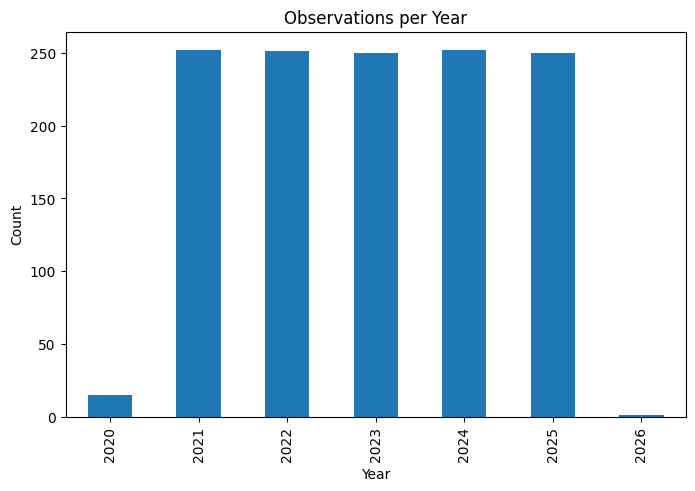

In [14]:
# Year Distribution
df['year'] = df['date'].dt.year

df['year'].value_counts().sort_index().plot(kind='bar', figsize=(8,5))
plt.title("Observations per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

**Insights**
* Stock Price Trading affected in the year 2020 due to Covid crisis
* From 2021 to 2025 the year distribution is approximately same
* 2026 is an ongoing year

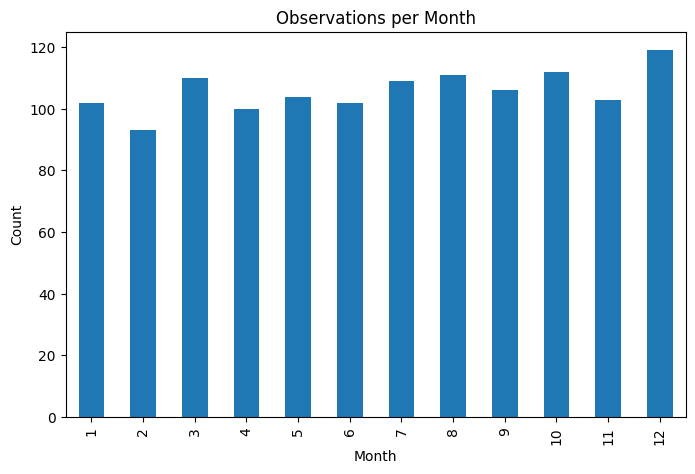

In [15]:
# Month Distribution
df['month'] = df['date'].dt.month

df['month'].value_counts().sort_index().plot(kind='bar', figsize=(8,5))
plt.title("Observations per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

**Insights**

- The dataset is well balanced across the year
- Lower counts in some months may indicate fewer trading days due to holidays or market closures.
- **The monthly distribution chart shows how observations are spread across different months. Most months have a similar number of records, indicating consistent data collection across the year. Slight variations may occur due to differences in trading days or market holidays.**

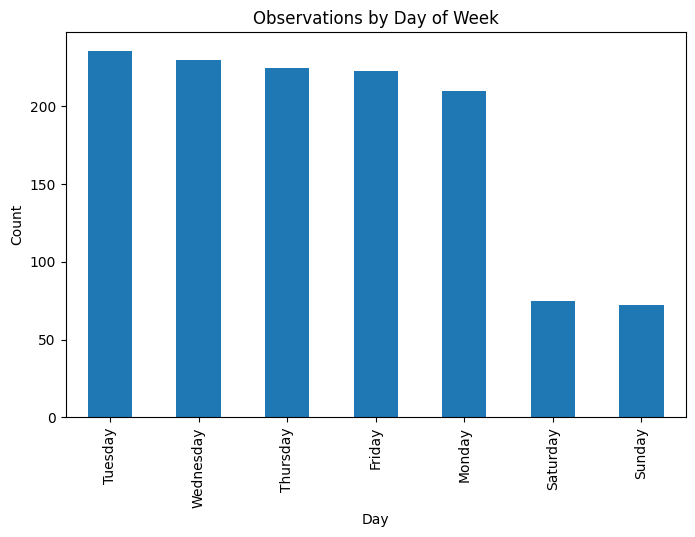

In [16]:
# Day of Week Distribution
df['day_name'] = df['date'].dt.day_name()

df['day_name'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Observations by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

**Insights**

- The dataset correctly reflects stock market trading days.
- **The day-of-week distribution shows that observations occur only on weekdays, which aligns with standard stock market trading schedules. The counts across Monday to Friday are relatively balanced, indicating consistent data availability across trading days. Minor variations may occur due to market holidays or exchange closures.**

In [17]:
# Time Series Density (Data Frequency Check)
df = df.sort_values('date')
df['date_diff'] = df['date'].diff().dt.days

df['date_diff'].value_counts().sort_index()

,count
date_diff,
1.0,905
2.0,185
3.0,143
4.0,32
5.0,1
6.0,1
31.0,1
32.0,2


**📊 Insights from date_diff Analysis**

**1️⃣ Majority of Observations Are 1-Day Gaps (905)**

* The dataset primarily follows a daily frequency structure.

* This confirms consistent time-series recording.

* Indicates stable trading-day continuity.

✅ Strong sign of good-quality daily data.


**2️⃣ 2-Day and 3-Day Gaps (185 & 143)**

* Likely represent weekend gaps:

* Friday → Monday = 3 days

* Holiday-adjusted weekends may create 2-day gaps

* These are expected in stock market data.

📌 This pattern confirms normal market closure behavior.


**3️⃣ 4-Day Gaps (32 occurrences)**

Likely caused by:

* Long weekends

* Public holidays

* Consecutive non-trading days

⚠️ Not abnormal, but worth noting in event analysis.


**4️⃣ Rare 5-Day and 6-Day Gaps (1 each)**

Suggest possible:

* Extended holiday periods

* Market disruptions

* Missing data entries

🔎 These should be manually inspected to confirm.


**5️⃣ Large Gaps: 31 and 32 Days**

* 31-day gap → 1 occurrence

* 32-day gap → 2 occurrences

🚨 These are significant breaks.

Possible reasons:

* Data collection interruption

* IPO start gap (if dataset begins after listing)

* Structural break in dataset

* Missing historical records

**Summary**

The dataset follows a consistent daily frequency structure, with most observations separated by one day. The presence of 2–3 day gaps reflects normal weekend and holiday market closures. A few extended gaps (31–32 days) indicate potential structural breaks or missing data, which should be considered during time-series modeling and rolling window calculations.

#### **Bivariate Analysis**

**Open vs Close Relationship**
- Does the stock usually close higher or lower than it opens?

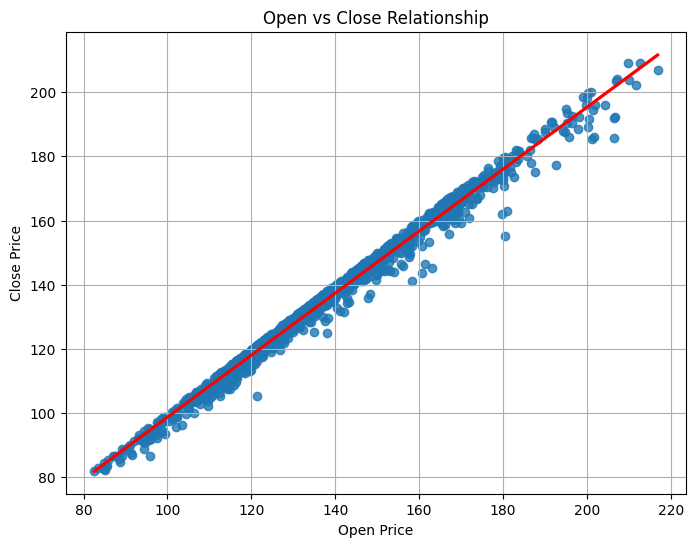

In [18]:
plt.figure(figsize=(8,6))
sns.regplot(x=df['open'], y=df['close'], line_kws={"color":"red"})
plt.title("Open vs Close Relationship")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

* The regression line slopes upward → **positive covariance**

In [19]:
# Calculating the covariance and correlation between the opening and cosing price

covariance = df['open'].cov(df['close'])
print("Covariance between Open and Close:", covariance)

correlation = df['open'].corr(df['close'])
print("Correlation between Open and Close:", correlation)

Covariance between Open and Close: 560.1925511779144
Correlation between Open and Close: 0.9943067774878555


If covariance is:

* **Positive** → When Open increases, Close tends to increase

* **Negative** → When Open increases, Close tends to decrease

* **Near 0** → Weak or no linear relationship

*The covariance between open and close price is 560.19 which shows the positive covariance between the two columns i.e when the open price increases the close price also increases.*

| Correlation Value | Meaning                           |
| ----------------- | --------------------------------- |
| 0.90 to 1.00      | Very strong positive relationship |
| 0.70 to 0.89      | Strong positive                   |
| 0.40 to 0.69      | Moderate positive                 |
| 0.00 to 0.39      | Weak positive                     |
| < 0               | Negative relationship             |


### 📊 Results

* **Covariance:** `560.19`
* **Correlation:** `0.9943`

---

# 🔎 1️⃣ What This Means

## ✅ Correlation = **0.9943** (Extremely Strong Positive)

This is **almost a perfect positive linear relationship**.

It means:

> When the **Open price increases**, the **Close price almost always increases proportionally**.

In practical terms:

* Airbnb rarely reverses direction drastically within the same day.
* The stock’s closing price is highly dependent on where it opened.
* Intraday movement is generally consistent with opening sentiment.

For stock data, this level (>0.99) is **very common** because:

* The closing price is built from the same trading session as the open.
* Prices move continuously.
* There is no large structural separation between open and close values.

---

# 🔎 2️⃣ What About the Covariance (560.19)?

Covariance confirms **positive movement together**, but:

⚠️ Covariance depends on the price scale.

Since Airbnb trades at relatively high price levels, the covariance value appears large.
That’s why **correlation (0.9943)** is the more meaningful metric.

---

# 🎯 Key Insight from Analysis Report

We can write:

> The correlation coefficient of 0.9943 indicates an extremely strong positive linear relationship between the opening and closing prices. This suggests high intraday price consistency, where daily closing prices closely follow the direction established at market open.


**Price vs Volume Relationship**
- Does high trading volume impact price movement?

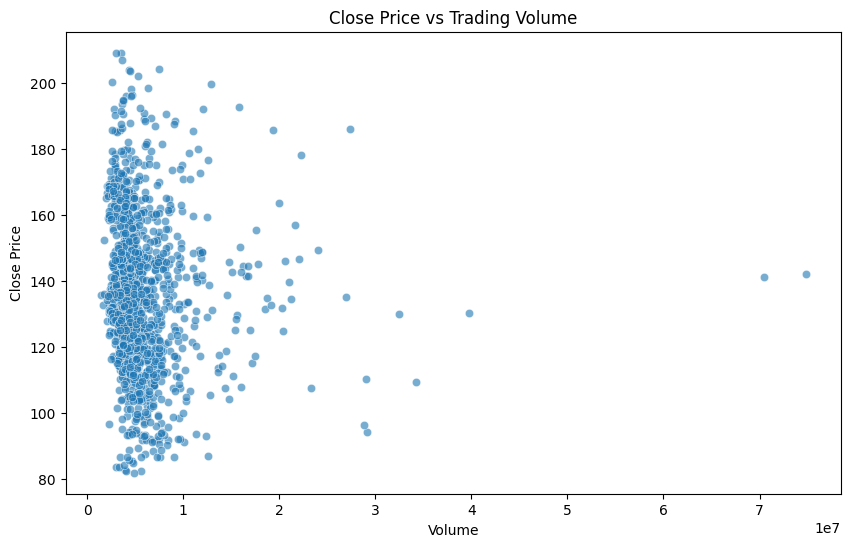

In [21]:
# Close Price vs Volume
# This shows whether higher volume leads to higher/lower prices
# Helps identify relationship between trading activity and price level

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['volume'],
    y=df['close'],
    alpha=0.6
)

plt.title("Close Price vs Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

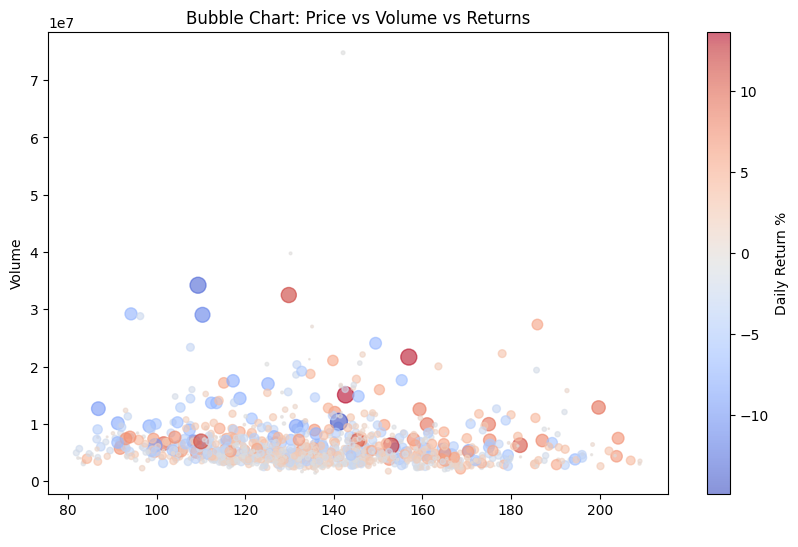

In [22]:
# Price vs Volume vs Returns
# Bubble size represents daily_return_pct

plt.figure(figsize=(10,6))

plt.scatter(
    df['close'],
    df['volume'],
    s=abs(df['daily_return_pct'])*10,
    c=df['daily_return_pct'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(label="Daily Return %")

plt.title("Bubble Chart: Price vs Volume vs Returns")
plt.xlabel("Close Price")
plt.ylabel("Volume")

plt.show()

Shows:

- **Big bubbles = large price movement**

- **Color = positive (red) or negative returns (blue)**

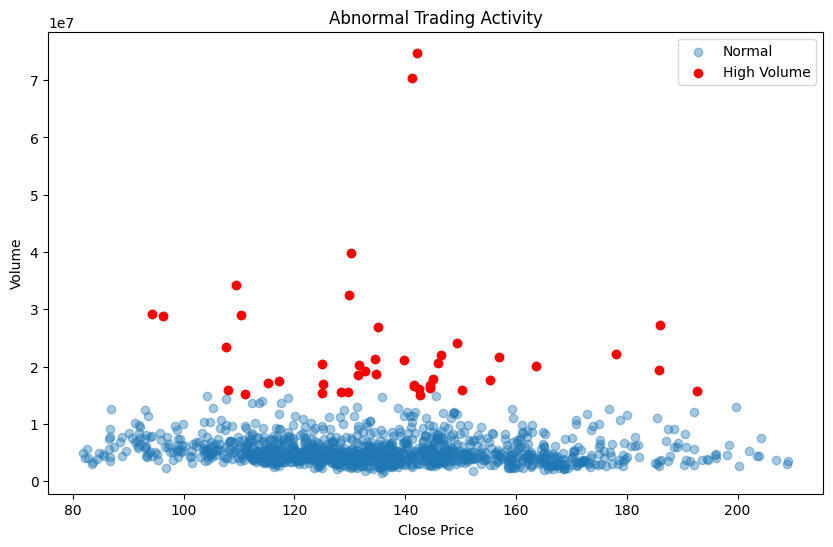

In [23]:
# Highlighting Abnormal Volume (Using Z-Score)
# column volume_zscore can detect unusual trading

high_volume = df[df['volume_zscore'] > 2]

plt.figure(figsize=(10,6))

plt.scatter(df['close'], df['volume'], alpha=0.4, label="Normal")

plt.scatter(
    high_volume['close'],
    high_volume['volume'],
    color='red',
    label='High Volume'
)

plt.title("Abnormal Trading Activity")
plt.xlabel("Close Price")
plt.ylabel("Volume")
plt.legend()

plt.show()

- **Points in red = abnormal trading activity**

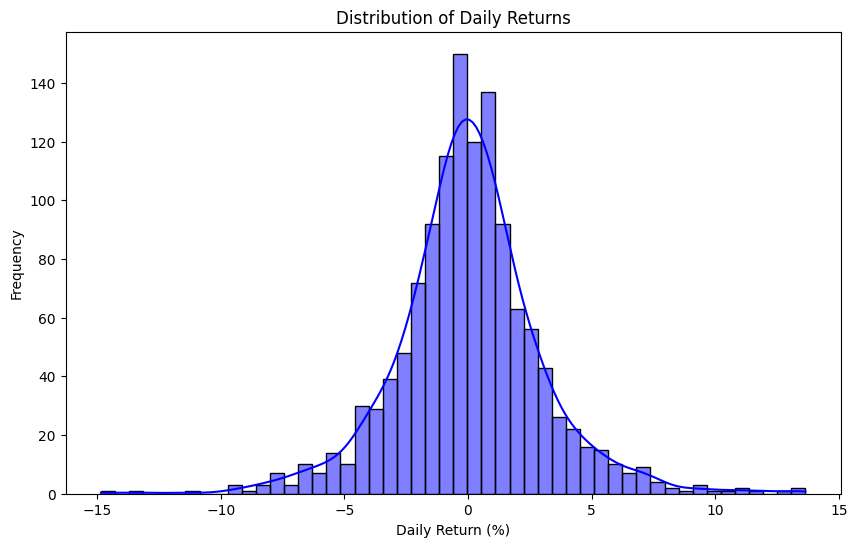

In [24]:
# Histogram of Daily Returns
# This shows the distribution of gains and losses

plt.figure(figsize=(10,6))

sns.histplot(df['daily_return_pct'], bins=50, kde=True, color='blue')

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

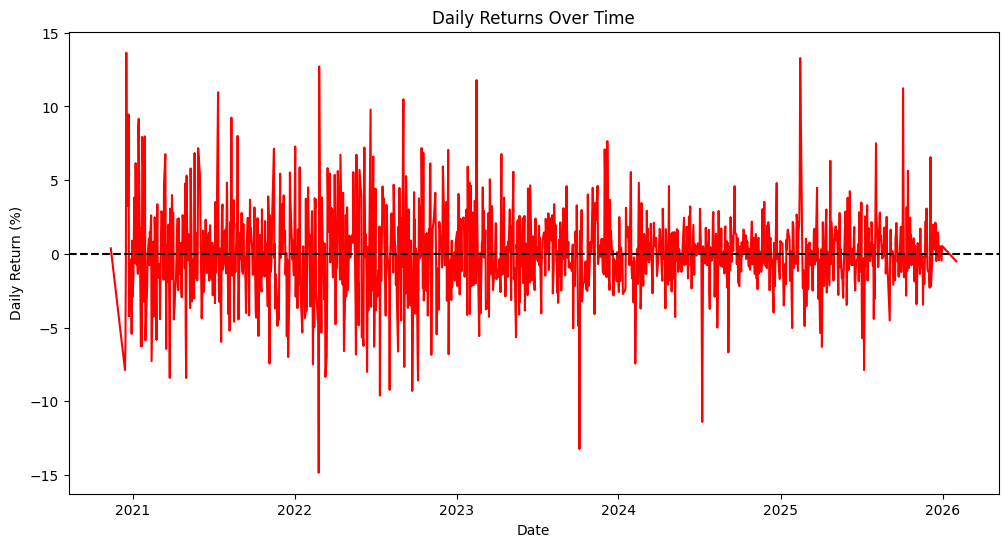

In [26]:
# Line Chart of Returns Over Time
# Shows how returns change day by day

plt.figure(figsize=(12,6))

plt.plot(df['date'], df['daily_return_pct'], color='red')

plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.axhline(0, color='black', linestyle='--')

plt.show()

**What it Shows**

- Positive values → profit days

- Negative values → loss days

- Spikes → high volatility periods

**Insights**

- The histogram shows that most daily returns cluster around 0%, indicating normal market fluctuations.

- The distribution has fat tails, suggesting occasional large gains or losses.

- The time series chart highlights volatility spikes, which may correspond to market news or economic events.

**Calculating Moving Averages**

- 20-day moving average (short-term trend)

- 50-day moving average (long-term trend)

In [27]:
df['MA20'] = df['close'].rolling(window=20).mean()
df['MA50'] = df['close'].rolling(window=50).mean()

**Ploting Close Price with Moving Averages**

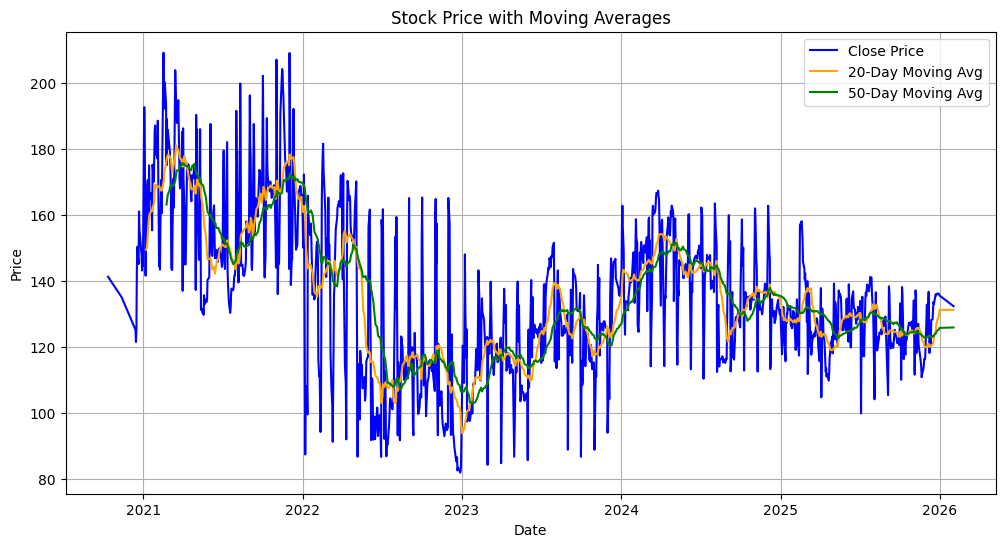

In [28]:
plt.figure(figsize=(12,6))

plt.plot(df['date'], df['close'], label="Close Price", color='blue')

plt.plot(df['date'], df['MA20'], label="20-Day Moving Avg", color='orange')

plt.plot(df['date'], df['MA50'], label="50-Day Moving Avg", color='green')

plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

**Identifying Trend Signals**

In [29]:
df['trend_signal'] = 0
df.loc[df['MA20'] > df['MA50'], 'trend_signal'] = 1
df.loc[df['MA20'] < df['MA50'], 'trend_signal'] = -1

print(df[['date','close','MA20','MA50','trend_signal']].tail())

           date       close       MA20        MA50  trend_signal
1266 2025-12-26  136.149994  128.22310  124.963139             1
1267 2025-12-29  136.160004  129.30785  125.232539             1
1268 2025-12-30  135.889999  130.28235  125.509439             1
1269 2025-12-31  135.565002  131.24060  125.764639             1
1270 2026-02-01  132.339996  131.21810  125.895639             1


**Signal Meaning**

- 1 → Bullish trend (uptrend)

- -1 → Bearish trend (downtrend)

- 0 → No clear signal

**Insight**

- The 20-day moving average captures short-term market momentum, while the 50-day average reflects longer-term trend direction.

- When the short-term average crosses above the long-term average, it indicates potential bullish momentum.

- Conversely, a downward crossover suggests possible bearish reversal.